In [1]:
%env NX_CURGAPH_AUTOCONFIG=True

import polars as pl
import holoviews as hv

import os
print(os.getcwd())

env: NX_CURGAPH_AUTOCONFIG=True
/home/joaot/myenv


In [2]:
df = pl.read_csv("merged_dedup.csv")

In [5]:
df['Authors'][0]

'Wu, Lingyun (57226766385); Hu, Zhiwen (59220407300); Liu, Jing (56808439100); Yu, Haitao (7405852172)'

In [3]:
import polars as pl
import cudf
import cugraph


# Assuming your main Polars DataFrame is called 'df'
# and the authors for each publication are in the 'Authors' column (as a string)

edges_list = []
all_authors = set()

for row in df.rows(named=True):
    if 'Authors' in row:
        authors_str = row['Authors']
        # Split the author string by semicolon
        authors = [author.strip() for author in authors_str.split(';')]

        for author in authors:
            all_authors.add(author)

        for i in range(len(authors)):
            for j in range(i + 1, len(authors)):
                author1 = authors[i]
                author2 = authors[j]
                if author1 < author2:
                    edges_list.append((author1, author2))
                elif author1 > author2:
                    edges_list.append((author2, author1))

# Create a mapping from author name to ID and vice versa
unique_authors = sorted(list(all_authors)) # Sorting for consistency
author_to_id = {author: i for i, author in enumerate(unique_authors)}
id_to_author = {i: author for author, i in author_to_id.items()}

edges_with_ids = [(author_to_id[u], author_to_id[v]) for u, v in edges_list if u in author_to_id and v in author_to_id]

# Create a CuDF DataFrame from the edge list with IDs
edges_gdf_ids = cudf.DataFrame({'source': [edge[0] for edge in edges_with_ids],
                                'destination': [edge[1] for edge in edges_with_ids]})

# Create a CuGraph graph from the edge list
cu_graph_ids = cugraph.from_cudf_edgelist(
    edges_gdf_ids,
    source='source',
    destination='destination',
)

# Perform Louvain community detection
partition_ids, modularity = cugraph.louvain(cu_graph_ids)

# Map the IDs back to author names
author_communities = {}
partition_pd = partition_ids.to_pandas()
for index, row in partition_pd.iterrows():
    author_id = int(row['vertex'])
    community_id = row['partition']
    if author_id in id_to_author:
        author_communities[id_to_author[author_id]] = community_id


In [4]:
import polars as pl
import cudf
import cugraph
from collections import Counter

# --- Part 1: Load Data and Extract Authors/Edges (from your script) ---

edges_list = []
all_authors = set()
author_paper_data = [] # Stores one entry per (author, paper) combination

for row_idx, row in enumerate(df.iter_rows(named=True)):
    if 'Authors' in row and row['Authors'] is not None:
        authors_str = row['Authors']
        authors_on_paper = [author.strip() for author in authors_str.split(';') if author.strip()]

        paper_affiliations_str = row.get('Affiliations', None)
        paper_affiliations_list = [] # Will be a list of strings
        if paper_affiliations_str:
            paper_affiliations_list = [aff.strip() for aff in paper_affiliations_str.split(';') if aff.strip()]
        
        paper_citations = row.get('Cite Count', 0)

        for author in authors_on_paper:
            all_authors.add(author)
            # Store author-paper relationship with paper-level metrics and affiliations
            author_paper_data.append({
                'author_name': author,
                'paper_id': row_idx,
                'paper_cite_count': paper_citations,
                'affiliation': paper_affiliations_list # Storing as a LIST of strings
            })

        # Generate co-authorship edges and count weights
        sorted_authors_on_paper = sorted(authors_on_paper)
        for i in range(len(sorted_authors_on_paper)):
            for j in range(i + 1, len(sorted_authors_on_paper)):
                author1 = sorted_authors_on_paper[i]
                author2 = sorted_authors_on_paper[j]
                
                pair = tuple(sorted([author1, author2]))
                edges_list.append(pair)

co_authorship_counts = Counter(edges_list)

# Create a mapping from author name to ID and vice versa
unique_authors = sorted(list(all_authors))
author_to_id = {author: i for i, author in enumerate(unique_authors)}
id_to_author = {i: author for author, i in author_to_id.items()}

# Prepare final edge list with weights
final_edges_data = []
for (u_name, v_name), weight in co_authorship_counts.items():
    u_id = author_to_id.get(u_name)
    v_id = author_to_id.get(v_name)
    if u_id is not None and v_id is not None:
        final_edges_data.append((u_id, v_id, weight))

# Create a CuDF DataFrame from the edge list with IDs and weights
edges_gdf_ids = cudf.DataFrame({
    'source': [edge[0] for edge in final_edges_data],
    'destination': [edge[1] for edge in final_edges_data],
    'weight': [edge[2] for edge in final_edges_data]
})

# Create a CuGraph graph from the edge list
cu_graph_ids = cugraph.from_cudf_edgelist(
    edges_gdf_ids,
    source='source',
    destination='destination',
    edge_attr='weight',
    renumber=False
)

# Perform Louvain community detection
partition_ids, modularity = cugraph.louvain(cu_graph_ids)
print(f"Modularity score: {modularity}")

# --- Part 2: Consolidate Node Metadata (Revised Robust Approach) ---

# 1. Create the Polars DataFrame for author-paper level data
author_paper_df = pl.DataFrame(author_paper_data)

# 2. Aggregate paper-level metrics (citations, num_publications) per author
#    This is done on the author_paper_df directly, avoiding overcounting
author_paper_level_metrics = author_paper_df.group_by('author_name').agg([
    pl.col('paper_cite_count').sum().alias('total_citations'),
    pl.col('paper_id').n_unique().alias('num_publications') # Counts unique papers
])

# 3. Aggregate unique affiliations per author
#    We explode the 'affiliation' list column first to flatten it
#    Then group by author_name to get unique affiliations
author_affiliation_metrics = author_paper_df.explode('affiliation').group_by('author_name').agg([
    pl.col('affiliation').unique().alias('unique_affiliations_list') # This collects all unique affiliations
]).with_columns([
    # Sort and join the unique affiliations into a string
    pl.col('unique_affiliations_list').list.sort().list.join("; ").alias('unique_affiliations_str')
]).drop('unique_affiliations_list') # Drop the intermediate list column

# 4. Join the two aggregated DataFrames (paper-level metrics and affiliations)
author_metrics_pl = author_paper_level_metrics.join(author_affiliation_metrics, on='author_name', how='left')


# 5. Add 'vertex' (author ID) to author_metrics_pl
author_id_mapping_pl = pl.DataFrame({
    'author_name': list(author_to_id.keys()),
    'vertex': list(author_to_id.values())
})

author_metrics_with_ids_pl = author_metrics_pl.join(author_id_mapping_pl, on='author_name', how='left')


# 6. Merge with community partitions and convert to CuDF
node_meta_gdf = partition_ids.copy()

author_metrics_for_gdf_pl = author_metrics_with_ids_pl.select([
    'vertex',
    'author_name',
    'total_citations',
    'num_publications',
    'unique_affiliations_str'
])

node_attributes_gdf_from_polars = cudf.DataFrame(author_metrics_for_gdf_pl.to_dicts())


final_node_meta_gdf = node_meta_gdf.merge(node_attributes_gdf_from_polars, on='vertex', how='left')

final_node_meta_gdf = final_node_meta_gdf.fillna({
    'total_citations': 0,
    'num_publications': 0,
    'unique_affiliations_str': ''
})

print("\nFinal Consolidated Node Metadata CuDF DataFrame (final_node_meta_gdf):")
print(final_node_meta_gdf.head())

Modularity score: 0.9591400853969803

Final Consolidated Node Metadata CuDF DataFrame (final_node_meta_gdf):
   vertex  partition                        author_name  total_citations  \
0    4416          3          Aymen, Abid (57191252921)              0.0   
1    4417       1313   Ayodele, Kayode P. (25654510000)              2.0   
2    4418       6574        Ayoobi, Navid (57652355800)              6.0   
3    4419          3  Ayrosa, Pedro P. S. (57217043957)             34.0   
4    4420          5     Ayton, Lauren N. (35101404100)             13.0   

   num_publications                            unique_affiliations_str  
0                 1  Advanced Fluid Dynamics Energetics and Environ...  
1                 1  Department of Electronic and Electrical Engine...  
2                 2  Stevens Institute of Technology, Department of...  
3                 1  Aston Robotics Vision and Intelligent Systems ...  
4                 1  Bionics Institute, East Melbourne, Australia; ..

In [13]:
partition_ids.value_counts()

vertex  partition
72184   7036         1
74455   1            1
85841   563          1
63580   5384         1
12442   1019         1
                    ..
63737   5115         1
30763   182          1
4159    100          1
50725   24           1
51148   29           1
Name: count, Length: 96569, dtype: int64


Applying filters:
- Edges: weight >= 2
- Nodes: total_citations >= 200 AND num_publications >= 10
Original edges: 357506 -> Filtered edges: 34273
Original nodes: 96569 -> Filtered nodes: 513

Re-building cugraph object with filtered edges and nodes...
Filtered cugraph object created.

Computing graph layout for filtered graph using cugraph.force_atlas2...
Layout computation complete for filtered graph.


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
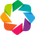


Computing graph layout using cugraph.force_atlas2...
Layout computation complete.



Top 20 Communities by Author Count (from filtered data):

Custom color mapping for legend:


In [ ]:
from bokeh.palettes import Category20
import panel as pn
from bokeh.resources import INLINE
# Define your culling thresholds here:
MIN_EDGE_WEIGHT = 2    # Keep only edges where authors co-authored at least 2 papers
MIN_NODE_CITATIONS = 200 # Keep authors with at least 50 total citations
MIN_NODE_PUBLICATIONS = 10 # Keep authors with at least 3 publications

print(f"\nApplying filters:")
print(f"- Edges: weight >= {MIN_EDGE_WEIGHT}")
print(f"- Nodes: total_citations >= {MIN_NODE_CITATIONS} AND num_publications >= {MIN_NODE_PUBLICATIONS}")

# 1. Filter Edges based on weight
filtered_edges_gdf = edges_gdf_ids[edges_gdf_ids['weight'] >= MIN_EDGE_WEIGHT]
print(f"Original edges: {len(edges_gdf_ids)} -> Filtered edges: {len(filtered_edges_gdf)}")

# 2. Identify all unique nodes (source or destination) present in the filtered edges
active_vertices_from_edges = cudf.concat([
    filtered_edges_gdf['source'],
    filtered_edges_gdf['destination']
]).unique()

# 3. Filter Nodes based on their metrics AND presence in the filtered edges
#    First, filter by node metrics
filtered_nodes_by_metrics_gdf = final_node_meta_gdf[
    (final_node_meta_gdf['total_citations'] >= MIN_NODE_CITATIONS) &
    (final_node_meta_gdf['num_publications'] >= MIN_NODE_PUBLICATIONS)
]
#    Then, filter this set further to only include nodes that are part of the filtered edges
filtered_nodes_gdf = filtered_nodes_by_metrics_gdf[
    filtered_nodes_by_metrics_gdf['vertex'].isin(active_vertices_from_edges)
]
print(f"Original nodes: {len(final_node_meta_gdf)} -> Filtered nodes: {len(filtered_nodes_gdf)}")

# --- Re-build cugraph object with ONLY the filtered data ---
# This is crucial for optimal layout computation
print("\nRe-building cugraph object with filtered edges and nodes...")
cu_graph_ids_filtered = cugraph.from_cudf_edgelist(
    filtered_edges_gdf,
    source='source',
    destination='destination',
    edge_attr='weight',
    renumber=False # Keep original IDs for merging with node metadata
)
print("Filtered cugraph object created.")

# --- Re-compute Layout with the Filtered Graph ---
print("\nComputing graph layout for filtered graph using cugraph.force_atlas2...")
layout_gdf_filtered = cugraph.force_atlas2(
    cu_graph_ids_filtered,
    max_iter=500, # Number of iterations for the layout algorithm. Adjust as needed.
)
print("Layout computation complete for filtered graph.")


final_node_meta_gdf_with_layout_filtered = filtered_nodes_gdf.merge(layout_gdf_filtered, on='vertex', how='left')

# --- Plotting with HoloViews (using pre-computed layout from filtered graph) ---
hv.extension('bokeh')

print("\nComputing graph layout using cugraph.force_atlas2...")
layout_gdf = cugraph.force_atlas2(
    cu_graph_ids,
    max_iter=500, # Number of iterations for the layout algorithm. Adjust as needed.
    edge_weight_influence=1, # Can be adjusted
    gravity=0.01,
    scaling_ratio=8, #should make graph more sparse but dont see it

)
print("Layout computation complete.")

hv.extension('bokeh') # Ensure HoloViews uses the Bokeh backend for interactivity

# Convert CuDF DataFrames to Pandas DataFrames for HoloViews compatibility
edges_df = edges_gdf_ids.to_pandas()
nodes_df_with_layout = final_node_meta_gdf_with_layout_filtered.to_pandas()


# --- NEW: Prepare Data for Legend ---

# 1. Count authors per community in the FILTERED data
community_counts_filtered = nodes_df_with_layout['partition'].value_counts().sort_values(ascending=False)
print("\nTop 20 Communities by Author Count (from filtered data):")

# 2. Get the IDs of the top 20 partitions
top_20_partition_ids = community_counts_filtered.head(20).index.tolist()

# 3. Create a new column 'community_label_for_legend' with descriptive string labels
#    Initialize all labels to 'Other Communities'
nodes_df_with_layout['community_label_for_legend'] = 'Other Communities'

# Prepare a list of colors for the top 20 communities from Category20
top_colors = Category20[20]

# Coulndt get it working
color_mapping_dict = {}
for i, pid in enumerate(top_20_partition_ids):
    label = f'Community {pid}'
    # Assign the label to nodes belonging to this top community
    nodes_df_with_layout.loc[nodes_df_with_layout['partition'] == pid, 'community_label_for_legend'] = label
    # Map the label to a color from Category20
    color_mapping_dict[label] = top_colors[i]
color_mapping_dict['Other Communities'] = 'lightgrey'

print("\nCustom color mapping for legend:")

# 1. Filter nodes to only those belonging to the top 20 partitions
nodes_in_top_communities = nodes_df_with_layout[
    nodes_df_with_layout['partition'].isin(top_20_partition_ids)
].copy()

# 2. For each of these top communities, find the index of the author with the max total_citations
#    This will give us the single row (node) to label for each community.
idx_max_citations_per_community = nodes_in_top_communities.loc[
    nodes_in_top_communities.groupby('partition')['total_citations'].idxmax()
]
# 2. Create Labels element using this filtered DataFrame
top_community_labels = hv.Labels(
    idx_max_citations_per_community,
    kdims=['x', 'y'],
    vdims=['partition']
).opts(
    text_font_size='8pt',
    text_color='black',
    text_align='center',
    text_baseline='middle',
    # Optionally, adjust text_alpha if labels are too dense
    # text_alpha=0.7
)

# Create HoloViews Nodes explicitly with x, y coordinates AND the node ID
nodes_hv_element = hv.Nodes(
    nodes_df_with_layout,
    kdims=['x', 'y', 'vertex'], # *** IMPORTANT FIX HERE: Add 'vertex' as the third key dimension ***
    vdims=[col for col in nodes_df_with_layout.columns if col not in ['x', 'y', 'vertex']] # Update vdims accordingly
)

# Create HoloViews Graph element by passing the pre-defined nodes element
graph = hv.Graph(
    (edges_df, nodes_hv_element),
    kdims=['source', 'destination'],
    vdims=['weight']
)

# Customize the plot using HoloViews opts
graph_plot = graph.opts(
    tools=['hover'],
    width=1000,
    height=800,
    bgcolor='#F8F8F8',
    padding=0.1,
    
    # *** IMPORTANT CHANGES FOR LEGEND ***
    node_color='community_label_for_legend', # Use the new string label column for coloring
    cmap=color_mapping_dict,                 # Use the dictionary mapping string labels to colors
    colorbar=False,                          # Disable the color bar
    

    node_line_width=0.5,
    node_size=hv.dim('total_citations').norm() * 50 + 10,
    
    edge_line_width=hv.dim('weight').norm() * 3 + 0.5,
    edge_line_color='grey',
    edge_alpha=0.6,

    xaxis=None, 
    yaxis=None,
    
    hover_tooltips=[
        ('Author Name', '@author_name'),
        ('Total Citations', '@total_citations'),
        ('Num Publications', '@num_publications'),
        ('Affiliations', '@unique_affiliations_str'),
        ('Community ID', '@partition') # Still show the original partition ID in hover
    ],
    
    title='Co-authorship Network: Communities, Citations, and Collaborations (ForceAtlas2 Layout)'
)

# Overlay the labels onto your graph plot
final_plot_with_labels = graph_plot * top_community_labels

# Display the plot
final_plot_with_labels

# --- NEW: Save the plot to an HTML file using Panel ---
output_filename = "co_authorship_network.html"
pn.pane.HoloViews(final_plot_with_labels).save(output_filename, embed=True, resources=INLINE)

In [34]:
top_community_nodes_df

,vertex,partition,author_name,total_citations,num_publications,unique_affiliations_str,x,y,community_label_for_legend
3,948,22,"Adeli, Hojjat (35612773100)",2030.0,11,"College of Engineering, Ohio State University,...",-244.927002,-787.269775,Community 22
6,7648,29,"Bleichner, Martin G. (36089082100)",803.0,15,"BlindSight GmbH, Schlitz, Germany; Center for ...",-1660.889038,-3122.815918,Community 29
7,6252,6,"Behera, Laxmidhar (6701522952)",249.0,15,"Centre for Artificial Intelligence, Faculty of...",993.672485,725.793884,Community 6
9,5046,19,"Bajaj, Varun (57209289122)",822.0,15,"Aarhus University, Department of Electrical an...",-1461.085327,-75.395233,Community 19
10,3632,32,"Aricò, Pietro (6506515949)",620.0,17,"'Sapienza' University of Rome, Rome, Italy; Au...",-9309.697266,-4122.943848,Community 32
...,...,...,...,...,...,...,...,...,...
506,86742,29,"Zappasodi, Filippo (6602811294)",431.0,14,BIND-Behavioral Imaging and Neural Dynamics Ce...,-934.796326,-2807.780029,Community 29
507,90125,5,"Zomorrodi, Reza (24167374300)",206.0,10,ATR Brain Information Communication Research L...,-5605.354492,-530.414429,Community 5
508,87910,23,"Zhang, Sicong (15754711700)",258.0,30,"Bioengineering College, Chongqing University, ...",837.272888,-2328.625000,Community 23
509,85286,5,"Yeasin, Mohammed (18039042000)",295.0,10,"Department of Anatomy and Neurobiology, Univer...",-5378.755859,1538.478882,Community 5


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
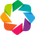

In [6]:
import cudf
import cugraph
import cupy as cp
import holoviews as hv
import datashader as ds
import datashader.transfer_functions as tf
from holoviews.operation.datashader import datashade
from bokeh.palettes import Category20
hv.extension('bokeh')


In [10]:
from collections import Counter
community_sizes = Counter(author_communities.values())
print(community_sizes.most_common(10))


[(6, 1502), (9, 1484), (0, 1460), (1, 1325), (2, 1150), (96, 1141), (21, 1033), (10, 1027), (27, 1019), (8, 1005)]


In [ ]:
centrality = cugraph.degree_centrality(cu_graph_ids)
central_authors = centrality.merge(partition_ids, on="vertex")
top_authors = central_authors.sort_values("degree_centrality", ascending=False).head(10)


In [ ]:
community_members = {}
for author, community_id in author_communities.items():
    if community_id not in community_members:
        community_members[community_id] = []
    community_members[community_id].append(author)

# iterate through community_members
# for community_id, members in community_members.items():
#    print(f"Community {community_id}: {len(members)} members")
#    # print(members) # Uncomment to see author names

In [30]:
import cudf

# Count authors per community
community_counts = partition_ids['partition'].value_counts().sort_values(ascending=False)
print(community_counts.head(10))


partition
1      1525
3      1386
0      1242
6      1196
2      1175
104    1141
14      997
5       994
11      984
25      981
Name: count, dtype: int64


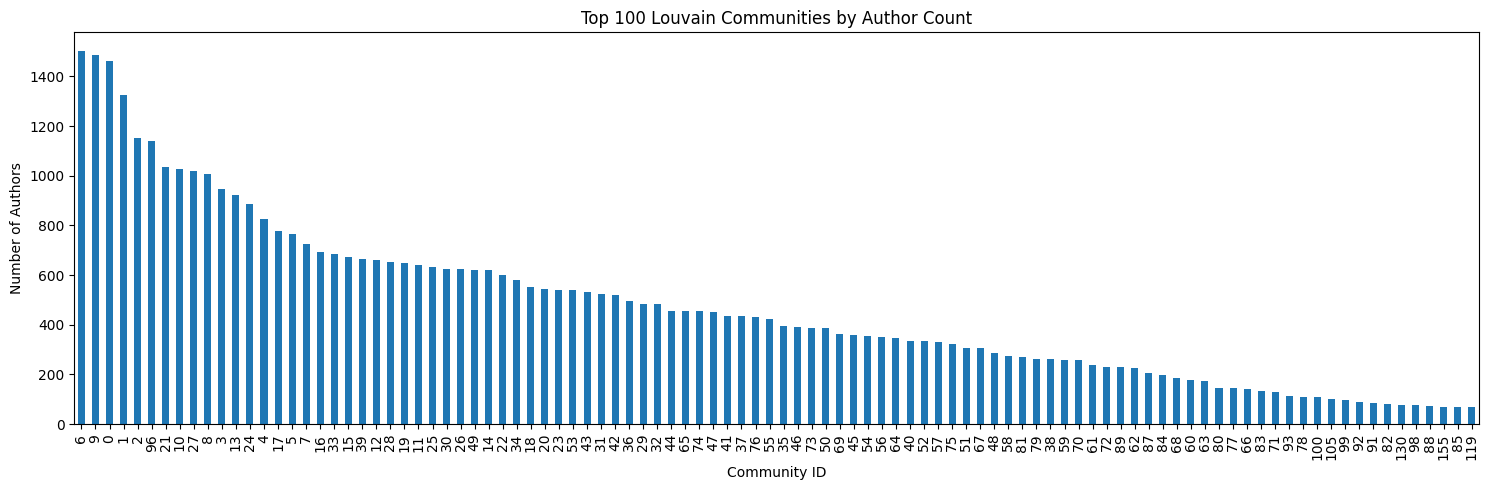

In [14]:
import matplotlib.pyplot as plt

# Convert to pandas for plotting
community_counts_pd = community_counts.to_pandas()

# Plot the top 10 communities
community_counts_pd.head(100).plot(kind='bar', figsize=(15, 5))
plt.xlabel("Community ID")
plt.ylabel("Number of Authors")
plt.title("Top 100 Louvain Communities by Author Count")
plt.tight_layout()
plt.savefig("Louvain 100.pdf")


In [ ]:
len(community_counts_pd)

7766

In [21]:
# Convert Louvain result to Polars
import polars as pl
df = df.with_columns([
    pl.col("Authors").fill_null("Unknown"),
    pl.col("Affiliations").fill_null("Unknown")
])
partition_pl = pl.DataFrame({
    "Author": [id_to_author[int(i)] for i in partition_ids['vertex'].to_arrow().to_pylist()],
    "Community": partition_ids['partition'].to_arrow().to_pylist()
})
# Explode authors and affiliations into rows
author_affil_rows = []

for row in df.rows(named=True):
    if "Authors" in row and "Affiliations" in row:
        authors = [a.strip() for a in row["Authors"].split(";")]
        affils = [a.strip() for a in row["Affiliations"].split(";")]
        for author in authors:
            for affil in affils:
                author_affil_rows.append({"Author": author, "Affiliation": affil})

# Convert to Polars
author_affil_df = pl.DataFrame(author_affil_rows)

# Join with community assignment
community_affils = partition_pl.join(author_affil_df, on="Author", how="inner")

target_comm = community_affils.filter(
    (pl.col("Community") == 6) & (pl.col("Affiliation") != "Unknown")
)
#target_comm = community_affils.filter(pl.col("Community") == 6)
# Count top institutions

#top_affils = target_comm.group_by("Affiliation").count().sort("count", descending=True)

top_affils = target_comm.group_by(
    pl.col("Affiliation").str.slice(0, 30).alias("Affiliation_Prefix_50")
).agg(
    # Get the first full affiliation string for each prefix group
    pl.col("Affiliation").first().alias("Original_Affiliation"),
    # Keep the count for the prefix group
    pl.count().alias("count")
).sort("count", descending=True) # Sort by count in descending order

print(top_affils.head(20))


shape: (20, 3)
┌────────────────────────────────┬─────────────────────────────────┬───────┐
│ Affiliation_Prefix_50          ┆ Original_Affiliation            ┆ count │
│ ---                            ┆ ---                             ┆ ---   │
│ str                            ┆ str                             ┆ u32   │
╞════════════════════════════════╪═════════════════════════════════╪═══════╡
│ Department of Biomedical Engin ┆ Department of Biomedical Engin… ┆ 325   │
│ Swartz Center for Computationa ┆ Swartz Center for Computationa… ┆ 308   │
│ Institute of Biomedical Engine ┆ Institute of Biomedical Engine… ┆ 213   │
│ State Key Laboratory on Integr ┆ State Key Laboratory on Integr… ┆ 166   │
│ Department of Computer Science ┆ Department of Computer Science… ┆ 163   │
│ …                              ┆ …                               ┆ …     │
│ Department of Physical Medicin ┆ Department of Physical Medicin… ┆ 65    │
│ Institute of Electrical Contro ┆ Institute of Electrical Co

/tmp/ipykernel_2355/1364528884.py:42: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("count")


In [22]:
print(top_affils["Original_Affiliation","count"].head(50).to_pandas().to_latex())

\begin{tabular}{llr}
\toprule
 & Original_Affiliation & count \\
\midrule
0 & Department of Biomedical Engineering, School of Life Sciences, Tiangong University, Tianjin, 300387, China & 325 \\
1 & Swartz Center for Computational Neuroscience, Institute of Neural Computation, University of California, La Jolla, San Diego, CA, United States & 308 \\
2 & Institute of Biomedical Engineering, Chinese Academy of Medical Sciences and Peking Union Medical College, Tianjin, 300192, China & 213 \\
3 & State Key Laboratory on Integrated Optoelectronics, Institute of Semiconductors, Chinese Academy of Sciences, Beijing, 100083, China & 166 \\
4 & Department of Computer Science and Information Engineering, Chang Gung University, Taoyuan, Taiwan & 163 \\
5 & Department of Electrical Engineering, Indian Institute of Technology, Kanpur, India & 141 \\
6 & Institute for Neural Computation and Institute of Engineering in Medicine, University of California San Diego, San Diego, CA, United States & 141 \

In [ ]:
import pandas as pd
top_affils_s=top_affils[:10]
# Convert to pandas
top_affils_pd = top_affils_s.to_pandas()

# Export to LaTeX
latex_str = top_affils_pd.to_latex(index=False)

# Optionally save to file
with open("top_affiliations.tex", "w", encoding="utf-8") as f:
    f.write(latex_str)


In [ ]:
from collections import Counter

all_author_counts = Counter()

for row in df.rows(named=True):
    if row["Authors"]:
        authors = [a.strip() for a in row["Authors"].split(";")]
        all_author_counts.update(authors)

top_authors = all_author_counts.most_common(20)
for author, count in top_authors:
    comm = author_communities.get(author, "Not in graph")
    print(f"Author: {author}, Publications: {count}, Community: {comm}")


In [72]:
# Compute betweenness centrality
betweenness_df = cugraph.betweenness_centrality(G, normalized=True)

# Map vertex IDs to authors
vertex_ids = betweenness_df['vertex'].to_arrow().to_pylist()
authors = [id_to_author[int(v)] for v in vertex_ids]

# Rebuild DataFrame
betweenness_df = cudf.DataFrame({
    "Author": authors,
    "betweenness_centrality": betweenness_df['betweenness_centrality']
})

# Sort and print
top_betweenness = betweenness_df.sort_values('betweenness_centrality', ascending=False)
print(top_betweenness.head(20))


                 Author  betweenness_centrality
3     A. Broniec-Wójcik                0.022801
0            A. Bagheri                0.020324
1              A. Basak                0.019795
2               A. Akan                0.019707
4            A. Al-Ezzi                0.019103
5             A. Aoyama                0.015222
8            A. B. Said                0.014730
7            A. Affanni                0.014521
12        A. C. Atencio                0.014272
11           A. Bussalb                0.014257
13          A. Cerquera                0.014098
6              A. Awang                0.013930
10          A. Cicuttin                0.013809
9   A. Borhani-Haghighi                0.013615
16      A. B. Benevides                0.013143
19         A. Bamdadian                0.013071
17      A. Balakrishnan                0.013051
24             A. Aymin                0.012868
18          A. Balbinot                0.012793
14         A. Chaudhuri                0

In [ ]:
components = cugraph.connected_components(G)
lcc_label = components['labels'].value_counts().idxmax()
lcc_vertices = components[components['labels'] == lcc_label]['vertex']
G_lcc = G.subgraph(lcc_vertices)

# Now recalculate centralities here:
pagerank_lcc = cugraph.pagerank(G_lcc)


In [3]:
df_a = df.with_columns(
    pl.col("Authors").map_elements(lambda x: x.split(";"), return_dtype=pl.List(pl.Utf8))
)
df_exploded = df_a.explode("Authors")
df_exploded = df_exploded.with_columns(
    pl.col("Authors")
    #.str.replace(r"\s*\(.*\)", "")      # Remove text in parentheses
    .str.strip_chars()                  # Remove leading and trailing whitespace
)
result = (
    df_exploded
    .group_by("Authors")
    .agg([
        pl.len().alias("count"),
        pl.col("Affiliations").first().alias("example_affiliation"),
        pl.col("Title").first().alias("example_Paper")
    ])
    .sort("count", descending=True)
    .head(20)
)

In [4]:
authors_to_check = result["Authors"].to_list()

df=df_exploded.filter(
    pl.col("Authors").is_in(authors_to_check)
)

In [5]:
authors_to_check

['Jung, Tzyy-Ping (7201389395)',
 'Ming, Dong (9745824400)',
 'Xu, Guanghua (55632209100)',
 'Pachori, Ram Bilas (14632337000)',
 'Wang, Yijun (7601519371)',
 'Guan, Cuntai (7101632622)',
 'Li, Xiaoli (57192497946)',
 'Yao, Dezhong (55558568500)',
 'Lee, Seong-Whan (7601390519)',
 'Xu, Minpeng (37076397600)',
 'Lin, Chin-Teng (8942403600)',
 'Rajaguru, Harikumar (58098437800)',
 'Hu, Bin (58594670300)',
 'Chen, Xun (36456894700)',
 'Cichocki, Andrzej (7103098626)',
 'Jin, Jing (55710410800)',
 'Bidelman, Gavin M. (26325449700)',
 'Prabhakar, Sunil Kumar (56402666900)',
 'Acharya, U. Rajendra (7004510847)',
 'Ko, Li-Wei (8308152000)']

In [6]:
# First get all papers that include your target authors
papers_with_top_authors = (
    df_exploded
    .filter(pl.col("Authors").is_in(authors_to_check))
    .select("Title")
    .unique()
)

# Then get all authors from those papers (including your target authors)
coauthor_edges = (
    df_exploded
    .filter(pl.col("Title").is_in(papers_with_top_authors["Title"]))
    # Join with target authors to create edges
    .join(
        df_exploded.filter(pl.col("Authors").is_in(authors_to_check)),
        on="Title",
        suffix="_target"
    )
    # Filter out self-pairs and create clean edge pairs
    .filter(pl.col("Authors") != pl.col("Authors_target"))
    .select([
        pl.col("Authors_target").alias("source"),
        pl.col("Authors").alias("target"),
        pl.col("Title")
    ])
    # Count collaborations as weights
    .group_by(["source", "target"])
    .agg([
        pl.len().alias("weight")
    ])
)

/tmp/ipykernel_80/1556207545.py:12: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  .filter(pl.col("Title").is_in(papers_with_top_authors["Title"]))


In [7]:
author_to_index = {author: idx for idx, author in enumerate(authors_to_check)}

coauthor_edges = (
    df_exploded
    .filter(pl.col("Title").is_in(papers_with_top_authors["Title"]))
    .join(
        df_exploded.filter(pl.col("Authors").is_in(authors_to_check)),
        on="Title",
        suffix="_target"
    )
    .filter(pl.col("Authors") != pl.col("Authors_target"))
    .select([
        pl.col("Authors_target").alias("source"),
        pl.col("Authors").alias("target"),
        pl.col("Title")
    ])
    .group_by(["source", "target"])
    .agg([
        pl.len().alias("weight")
    ])
    .with_columns(
        pl.col("source").map_elements(lambda x: author_to_index.get(x, -1), return_dtype=pl.Int64).alias("source_index")
    )
)

/tmp/ipykernel_80/2178720029.py:5: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  .filter(pl.col("Title").is_in(papers_with_top_authors["Title"]))


In [8]:
coauthor_edges

source,target,weight,source_index
str,str,u32,i64
"""Yao, Dezhong (55558568500)""","""Zhao, Lingling (57209366375)""",2,7
"""Rajaguru, Harikumar (580984378…","""Babu, C. Ganesh (59152733500)""",1,11
"""Xu, Guanghua (55632209100)""","""Li, Lili (55774470700)""",6,3
"""Wang, Yijun (7601519371)""","""Liu, Yonghui (57202080195)""",1,4
"""Chen, Xiaogang (55621717700)""","""Huang, Xiaoshan (56252236100)""",2,19
…,…,…,…
"""Xu, Guanghua (55632209100)""","""Wurdemann, Helge (35119695800)""",1,3
"""Lee, Seong-Whan (7601390519)""","""Kim, Hong-Kyung (57208737160)""",1,8
"""Lee, Seong-Whan (7601390519)""","""Park, Ji-Ha (58729562700)""",1,8


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
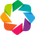

:Overlay
   .Graph.I  :Graph   [start,end]   (weight,source_index)
   .Labels.I :Labels   [x,y]   (author)

In [9]:
import networkx as nx
import holoviews as hv
import pandas as pd
from holoviews import opts

# 1. Create NetworkX graph
G = nx.from_pandas_edgelist(
    coauthor_edges.to_pandas(),
    source='source',
    target='target',
    edge_attr=['weight','source_index']
)

# 2. Compute layout
pos = nx.spring_layout(G, k=0.15, iterations=50)



# 3. Prepare nodes DataFrame with highlight info
nodes_df = pd.DataFrame({
    'index': list(G.nodes()),
    'x': [pos[node][0] for node in G.nodes()],
    'y': [pos[node][1] for node in G.nodes()],
    'author': list(G.nodes()),
    'degree': [d for n, d in G.degree()],
    'highlight': [1 if node in authors_to_check else 0 for node in G.nodes()],
    'size': [12 if node in authors_to_check else 8 for node in G.nodes()]  # Different sizes
})

# 4. Prepare edges
edges_df = coauthor_edges.to_pandas().rename(columns={
    'source': 'start',
    'target': 'end'
})

# 5. Create visualization with labels for highlighted authors
hv.extension('bokeh')
# Convert A4 dimensions to pixels (assuming 100dpi)
a4_width = 827
a4_height = 1169 
# Create Nodes with all attributes
nodes = hv.Nodes(
    data=nodes_df,
    kdims=['x', 'y', 'index'],
    vdims=['author', 'degree', 'highlight', 'size']
)

# Create Graph
graph = hv.Graph((edges_df, nodes))

# Create labels only for highlighted authors
labels = hv.Labels(
    data=nodes_df[nodes_df['highlight'] == 1],  # Only show labels for highlighted nodes
    kdims=['x', 'y'],
    vdims=['author']
)

# Define styling
highlight_cmap = {1: '#ff8c8c', 0: '#CCCCCC'}  # Red for highlighted, gray for others

# Combine graph and labels
final_plot = (graph * labels).opts(
    opts.Graph(
        width=a4_height,
        height=a4_width,
        node_size='size',
        node_color='highlight',
        cmap=highlight_cmap,
        edge_cmap='viridis',
        node_line_color='black',
        node_line_width=0.5,
        edge_line_width=1,
        edge_color='source_index',
        tools=['hover'],
        inspection_policy='nodes',
        xaxis=None,
        yaxis=None,
        show_frame=False,
    ),
    opts.Labels(
        text_font_size='10pt',
        text_color='black',
        #text_align='left',
        #text_baseline='middle',
        xoffset=0.01,  # Offset labels slightly to the right of nodes
        yoffset=0,
        text_font_style='bold'
    )
)

# Display
final_plot

In [46]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import numpy as np # For potential numeric operations

# 1. Create NetworkX graph
G = nx.from_pandas_edgelist(
    coauthor_edges.to_pandas(),
    source='source',
    target='target',
    edge_attr=['weight', 'source_index']
)

# 2. Compute layout
#pos = nx.spring_layout(G, k=0.15, iterations=50)
pos = nx.kamada_kawai_layout(G)


pos_pre=pos.copy()

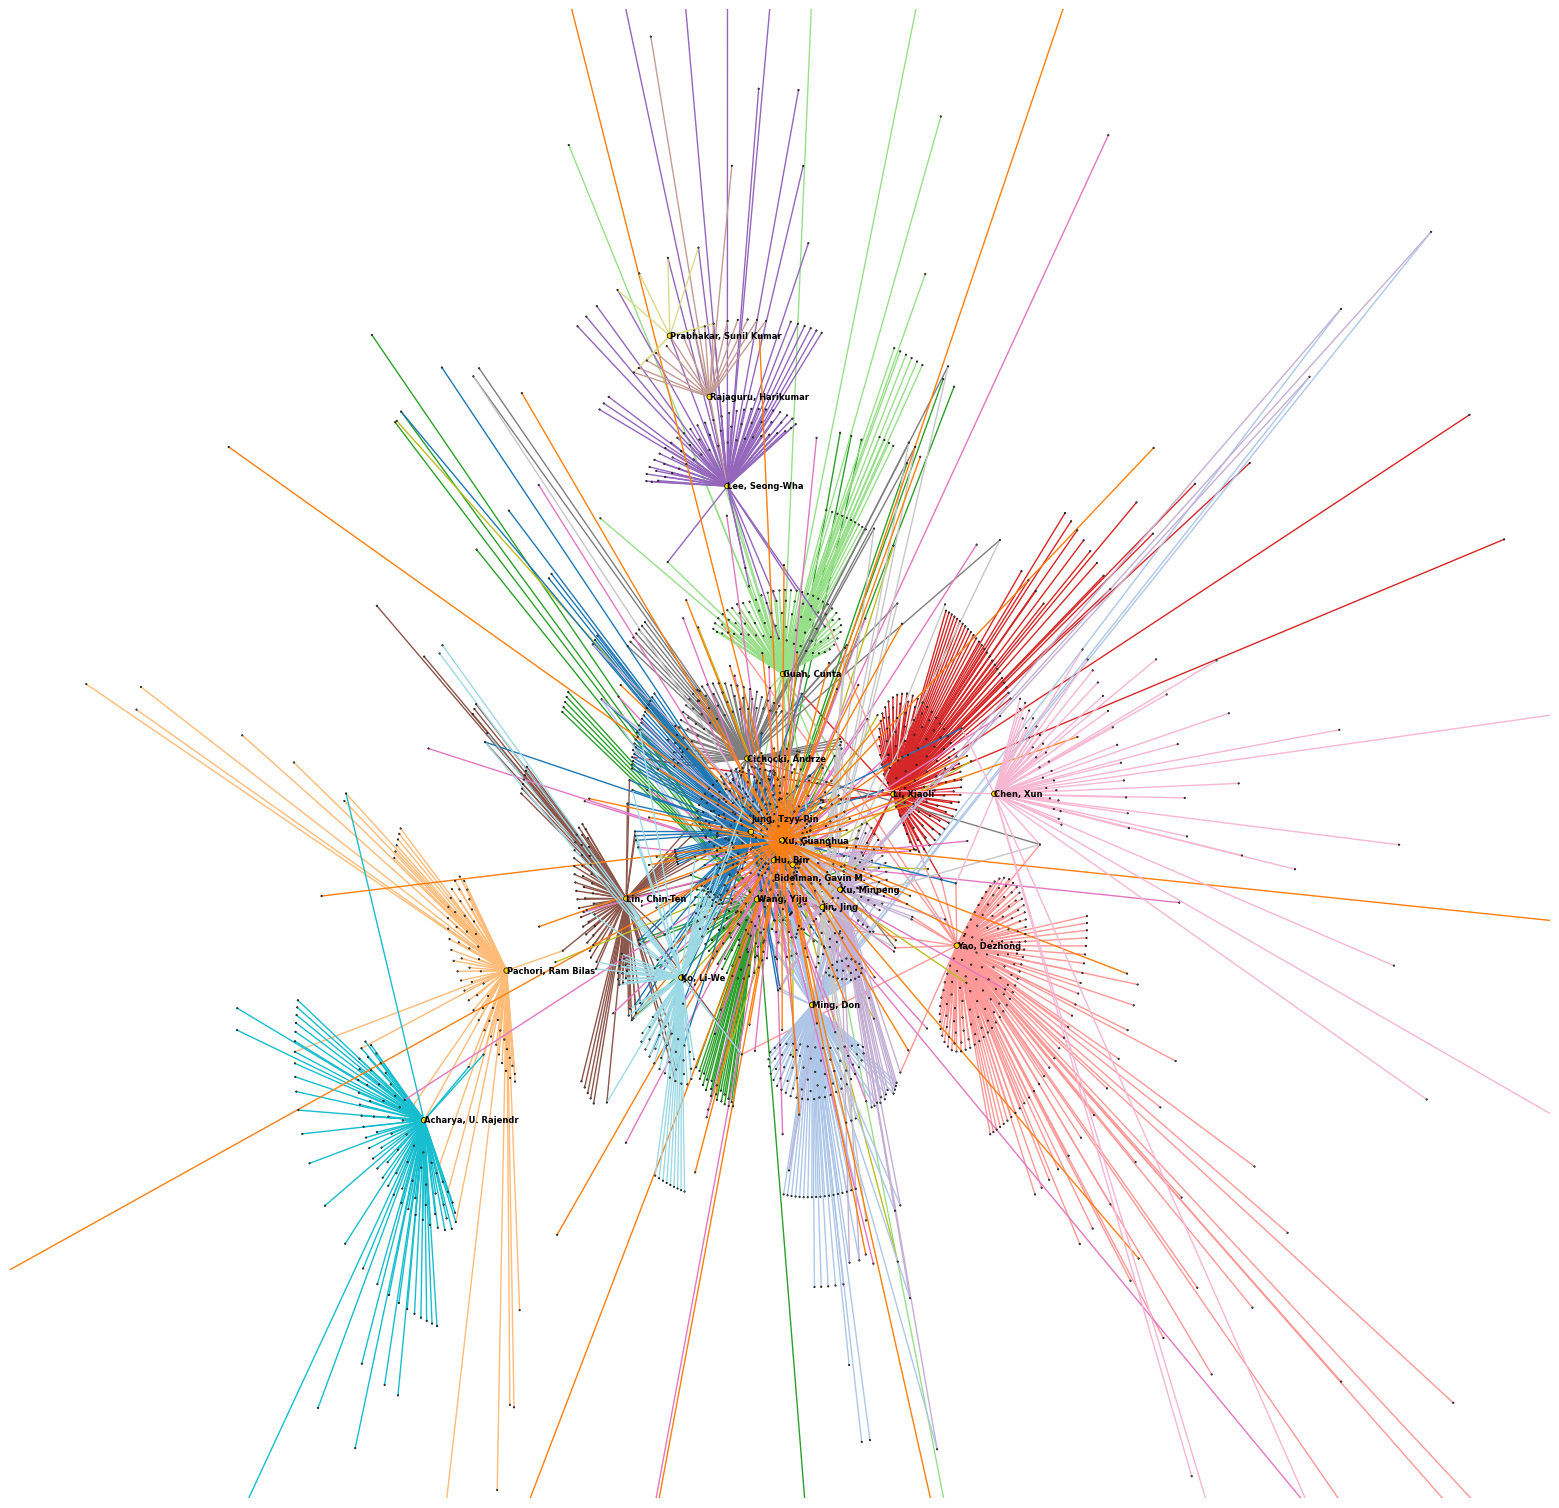

In [150]:
pos=pos_pre.copy()
sparse_factor = 1 # Experiment with this value

for node in pos:
    pos[node] = pos[node] * sparse_factor


original_node_ids = list(G.nodes())


sliced_author_ids = [str(node_id)[-4:] for node_id in original_node_ids]
# 3. Prepare nodes DataFrame with highlight info (already done in your code, good)
nodes_df = pd.DataFrame({
    'index': list(G.nodes()),
    'x': [pos[node][0] for node in G.nodes()],
    'y': [pos[node][1] for node in G.nodes()],
    'author': list(G.nodes()),
    'degree': [d for n, d in G.degree()],
    'highlight': [1 if node in authors_to_check else 0 for node in G.nodes()],
    'size': [3 if node in authors_to_check else 1 for node in G.nodes()]
})
# Map highlight to node colors using the custom colormap
node_colors_data = nodes_df['highlight'].map({1: '#FFD700', 0: '#CCCCCC'})
# Convert sizes to Matplotlib-compatible values (often need to scale up for visibility)
node_sizes = nodes_df['size'] * 1 # Adjust multiplier as needed for visual size
base_size_multiplier = 1
highlight_size_multiplier=5
node_sizes = nodes_df['size'] * nodes_df['highlight'].map({
    1: highlight_size_multiplier,
    0: base_size_multiplier
})
# 4. Prepare edges (no specific prep needed beyond what NetworkX handles)
# Get edge colors based on 'source_index'
edge_source_indices = [G.get_edge_data(u, v)['source_index'] for u, v in G.edges()]
# Create a colormap for edges (e.g., 'viridis')
edge_cmap = plt.cm.tab20
edge_colors = edge_cmap(np.array(edge_source_indices) / max(edge_source_indices)) # Normalize for colormap

# 5. Create Matplotlib figure and axes
# Convert A4 dimensions (pixels at 100dpi) to inches
# 1 inch = 100 pixels, so A4 width = 8.27 inches, height = 11.69 inches
a4_width_inches = 8.27 # Your original height (1169px) was width in landscape for bokeh
a4_height_inches = 11.69 # Your original width (827px) was height in landscape for bokeh

# For landscape, we swap them:
fig, ax = plt.subplots(figsize=(a4_height_inches*2, a4_width_inches*2)) # Width, Height
plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05)
# Draw nodes
nx.draw_networkx_nodes(G, pos,
                       node_color=node_colors_data.tolist(), # Convert to list for `draw_networkx_nodes`
                       node_size=node_sizes.tolist(),
                       edgecolors='black', # Node line color
                       linewidths=0.5,     # Node line width
                       ax=ax)

# Draw edges
nx.draw_networkx_edges(G, pos,
                       edge_color=edge_colors,
                       width=1,
                       ax=ax)

# Add labels for highlighted authors
j=0.001
k=0
for node, (x, y) in pos.items():
    if node in authors_to_check:
        if "Jung, Tzyy-Ping (7201389395)" == node :
            k=0.005
        elif 'Bidelman, Gavin M. (26325449700)' == node:
            j=-0.01
            k=-0.005
        else:
            j=0
            k=0
        ax.text(x + j, y+k,  # xoffset, yoffset (adjust as needed relative to graph scale)
                node[:-14],        # The author name
                fontsize=6,
                color='black',
                fontweight='bold',
                horizontalalignment='left',
                verticalalignment='center') # Adjust vertical alignment as needed


# Customize the plo
ax.set_aspect(1.4142857) # Maintain aspect ratio
ax.set_xticks([]) # Remove x-axis ticks
ax.set_yticks([]) # Remove y-axis ticks
ax.set_frame_on(False) # Remove frame (equivalent to show_frame=False)
value=0.3
xmax,ymax=(value* 1.4142857,value)
ax.set_xlim(xmax*-1,xmax)
ax.set_ylim((ymax*-1)+0.05, ymax+0.03)
plt.savefig("Author Edges.pdf") 
#plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

### results=result.with_columns(pl.col("Authors").str.extract(r"\((\d+)\)", group_index=1).alias("author_number"))


In [132]:
node_sizes

0       6
1       2
2       6
3       2
4       6
       ..
1824    2
1825    2
1826    2
1827    2
1828    2
Name: size, Length: 1829, dtype: int64

In [8]:
scopus_metric=pl.read_parquet("Author_metrics.parquet")
final=pl.concat([results,scopus_metric],how="horizontal")
pl.Config().set_tbl_rows(20)
df_transformed = final.with_columns([
    # Access the first (and only) inner list using list.get(0)
    # Then extract the second element (index 1) for 'International collaboration'
    pl.col("Collaboration percent").list.get(0).list.get(1).alias("International Collaboration"),

    # Extract the third element (index 2) for 'Academic-Corporate collaboration'
    pl.col("Collaboration percent").list.get(0).list.get(2).alias("Academic Corporate Collaboration"),
    pl.col("Goal_C").list.get(0).list.eval(pl.element().cast(pl.Int64)) # Cast string counts to integers within the list
    .list.arg_max() # Find the index of the maximum integer in each list
    .alias("max_goal_index"), # Assign a temporary name for this intermediate Series
    pl.col("Topic").list.get(0).list.get(0).alias("Topic"),
    pl.col("Topic").list.get(0).list.get(1).alias("2nd Topic"),
    pl.col("Topic").list.get(0).list.get(3).alias("3rd Topic"),
])
df_transformed=df_transformed.with_columns(pl.col("Goal")
    .list.get(0) # Get the inner list of Goal names (e.g., ['Goal 3', 'Goal 4', 'Goal 11'])
    .list.get(pl.col("max_goal_index")) # Use the 'max_goal_index' Series to extract the element
    .str.extract(r"Goal (\d+):.*", 1)
    .alias("Most Prominent Goal")
)
df_transformed = df_transformed.drop(["example_affiliation","Topic_c","author_number","Collaboration","Collaboration percent","max_goal_index","Goal","Goal_C","Co-Author","Co-Author_C"])

df_transformed=df_transformed.rename({
    "count": "Count in the query",
    #"example_affiliation":"Affiliation",
    "example_Paper":"Example Paper",
    "Topic": "1st Topic"
})

df_transformed=df_transformed.select([
    'Authors',
    'Count in the query',
    #'Affiliation',
    #'Example Paper',
    '1st Topic',
    '2nd Topic',  
    '3rd Topic',
    'Most Prominent Goal',
    'International Collaboration',
    'Academic Corporate Collaboration',
    'FWCI',
    'Documents in top citation percent',
    'Documents in top citation count',
    'Documents in top 25% journals percent',
    'Documents in top 25% journals count'
])



In [15]:
df_processed = df_transformed.with_columns(
    pl.col("International Collaboration")
    .str.replace("%", "")
    .cast(pl.Float64)
    .truediv(100)
    .alias("International Collaboration_float"), # Unique alias

    pl.col("Academic Corporate Collaboration")
    .str.replace("%", "")
    .cast(pl.Float64)
    .truediv(100)
    .alias("Academic Corporate Collaboration_float") # Unique alias
)

In [17]:
df_processed.mean()

Authors,Count in the query,1st Topic,2nd Topic,3rd Topic,Most Prominent Goal,International Collaboration,Academic Corporate Collaboration,FWCI,Documents in top citation percent,Documents in top citation count,Documents in top 25% journals percent,Documents in top 25% journals count,International Collaboration_float,Academic Corporate Collaboration_float
str,f64,str,str,str,str,str,str,str,str,str,str,str,f64,f64
null,50.25,null,null,null,null,null,null,null,null,null,null,null,0.6237,0.35205


In [9]:
print(df_transformed.to_pandas().to_latex())

\begin{tabular}{llrlllllllllll}
\toprule
 & Authors & Count in the query & 1st Topic & 2nd Topic & 3rd Topic & Most Prominent Goal & International Collaboration & Academic Corporate Collaboration & FWCI & Documents in top citation percent & Documents in top citation count & Documents in top 25% journals percent & Documents in top 25% journals count \\
\midrule
0 &  Jung, Tzyy-Ping (7201389395) & 87 & Steady-State Visual Evoked Potentials in Brain-Computer Interfaces & Brain-Computer Interface Systems & Neural Oscillations in Memory and Perception & 3 & 73.7% & 2.7% & 2.29 & 67.9% & 110 & 67.9% & 110 \\
1 &  Ming, Dong (9745824400) & 71 & Brain-Computer Interface Systems & Steady-State Visual Evoked Potentials in Brain-Computer Interfaces & Brain-Computer Interfaces for Motor Rehabilitation & 3 & 43% & 13.4% & 1.01 & 31.7% & 140 & 43% & 167 \\
2 &  Pachori, Ram Bilas (14632337000) & 64 & Innovative Approaches in Epileptic Seizure Detection & Brain-Computer Interface Systems & Deep Learn

In [ ]:
pl.Config.set_tbl_rows(20)
print(results["author_number"])

shape: (20,)
Series: 'author_number' [str]
[
	"7201389395"
	"9745824400"
	"14632337000"
	"55632209100"
	"7601519371"
	…
	"36456894700"
	"8885333800"
	"58026507100"
	"26435347900"
	"7004563459"
]


In [ ]:
pl.Config.set_tbl_rows(20)
print(results["author_number"])

shape: (20,)
Series: 'author_number' [str]
[
	"7201389395"
	"9745824400"
	"14632337000"
	"55632209100"
	"7601519371"
	…
	"36456894700"
	"8885333800"
	"58026507100"
	"26435347900"
	"7004563459"
]


In [9]:
# Find duplicated author names
result_df = result_df.with_columns(
    pl.col("AuthorsList").is_duplicated().alias("is_duplicate")
)

# Filter to only show duplicated authors with their titles
duplicated_authors = result_df.filter(pl.col("is_duplicate"))

In [ ]:
# First create the exploded DataFrame as before
result_df = df.select(
    ["Title", "Authors"]
).with_columns(
    pl.col("Authors").map_elements(lambda x: x.split(";")).alias("AuthorsList")
).explode("AuthorsList")

# Group by author name and collect all titles where each author appears
author_titles = result_df.group_by("AuthorsList").agg(
    pl.col("Title").alias("Titles_appeared_in")
)

# Filter to only show authors that appear in multiple titles
repeated_authors = author_titles.filter(pl.col("Titles_appeared_in").list.len() > 1)

In [ ]:
repeated_authors.write_parquet("name_disambiguate.parquet")

Code below stopped working probably changes to google scholar api that publish or perish didnt fix update yet

In [ ]:

author=result["Authors"][0]
title=result["example_title"][0]
if len(title)>100:
    split_t=title.split()
    split_t=split_t[:(len(split_t)//2)]
    title=' '.join(split_t)
print(title)
a=get_google_scholar_citations_url(author,title)

In [ ]:


import subprocess
import re
import pandas as pd
import os

def get_google_scholar_citations_url(author_name):
    """Retrieves the Google Scholar Citations URL for a given author."""
    try:
        command = [
            r"C:\Program Files\Harzing's Publish or Perish 8\pop8query.exe",
            "--gsauthor",
            "--author",
            f'"{author_name.strip()}"'  # Strip whitespace from author name
        ]
        result = subprocess.run(command, capture_output=True, text=True, check=True)
        if result.stdout is not None:
            output_lines = result.stdout.strip().split('\n')
            print(output_lines)
            match = re.search(r"https:\/\/scholar\.google\.com\/citations\?hl=en&user=([a-zA-Z0-9]+)", result.stdout)
            if match:
                return match.group(1)  # Return only the user ID
        else:
            print(f"Error: No output received from pop8query.exe for '{author_name.strip()}'")
            return None
        return None
    except subprocess.CalledProcessError as e:
        print(f"Error getting Citations URL for '{author_name.strip()}': {e}")
        return None
    except FileNotFoundError:
        print("Error: pop8query.exe not found.")
        return None
    except Exception as e:
        print(f"An unexpected error occurred in get_google_scholar_citations_url: {e}")
        return None


def get_author_data_from_url(author_id):
    """Retrieves profile ID, name, affiliation, and metrics for a given Google Scholar author ID using direct regex with error handling."""
    author_data = {}
    try:
        command = [
            r"C:\Program Files\Harzing's Publish or Perish 8\pop8query.exe",
            "--gsprofile",
            "--author",
            author_id,
            "--max",
            '5',
            "--format",
            "rtf"  # Request RTF format
        ]
        result = subprocess.run(command, capture_output=True, check=True)  # Don't decode text here

        try:
            text = result.stdout.decode('utf-8', errors='ignore') # Try UTF-8 with ignore
        except UnicodeDecodeError:
            text = result.stdout.decode('cp1252', errors='ignore') # Fallback to CP1252 with ignore

        try:
            author_data['Profile ID'] = re.search(r"Profile ID:} (.*)\\line", text)[1].strip()
            author_data['Profile Name and Affiliation'] = re.search(r"Profile name:} (.*)\\line", text)[1].strip()
            author_data['Labels'] = re.search(r"Profile labels:} (.*)\\line", text)[1].strip()
            author_data['Publication years'] = re.search(r"Publication years:} (.*)\\line", text)[1].strip()
            author_data['Citation years'] = re.search(r"Citation years:} (.*)\\line", text)[1].strip()
            author_data['Papers'] = re.search(r"Papers:} (.*)\\line", text)[1].strip()
            author_data['Citations'] = re.search(r"Citations:} (.*)\\line", text)[1].strip()
            author_data['Citations/year'] = re.search(r"Citations/year:} (.*)\\line", text)[1].strip()
            author_data['Citations/paper'] = re.search(r"Citations/paper:} (.*)\\line", text)[1].strip()
            author_data['Citations/author'] = re.search(r"Citations/author:} (.*)\\line", text)[1].strip()
            author_data['Papers/author'] = re.search(r"Papers/author:} (.*)\\line", text)[1].strip()
            author_data['Authors/paper'] = re.search(r"Authors/paper:} (.*)\\line", text)[1].strip()
            author_data['Age-weighted citation rate'] = re.search(r"Age-weighted citation rate:} (.*)\\line", text)[1].strip()
            author_data['Hirsch h-index'] = re.search(r"Hirsch h-index:} (.*)\\line", text)[1].strip()
            author_data['Egghe g-index'] = re.search(r"Egghe g-index:} (.*)\\line", text)[1].strip()
            author_data['PoP hI,norm'] = re.search(r"PoP hI,norm:} (.*)\\line", text)[1].strip()
            author_data['PoP hI,annual'] = re.search(r"PoP hI,annual:} (.*)\\line", text)[1].strip()
            author_data['Fassin hA-index'] = re.search(r"Fassin hA-index:} (.*)\\line", text)[1].strip()
        except AttributeError as e:
            print(f"Error finding a pattern in the output for author ID {author_id}: {e}")
            return None

        return author_data

    except subprocess.CalledProcessError as e:
        print(f"Error getting data for ID '{author_id}': {e}")
        print(f"Stderr: {e.stderr.decode(errors='ignore')}")
    except FileNotFoundError:
        print("Error: pop8query.exe not found.")
    except Exception as e:
        print(f"An unexpected error occurred while getting author data: {e}")
    return None

if __name__ == "__main__":
    author_names = [' Ming, Dong',
                    ' Jung, Tzyy-Ping',
                    ' Gao, Xiaorong',
                    ' Pachori, Ram Bilas',
                    ' Xu, Guanghua',
                    ' Wang, Yijun',
                    ' Guan, Cuntai',
                    ' Li, Xiaoli',
                    ' Yao, Dezhong',
                    ' Hu, Bin',
                    ' Lee, Seong-Whan',
                    ' Lin, Chin-Teng',
                    ' Xu, Minpeng',
                    ' Wang, Jing',
                    ' Cichocki, Andrzej',
                    ' Xu, Peng',
                    ' Chen, Wei',
                    ' Acharya, U. Rajendra',
                    ' Jin, Jing',
                    ' Chen, Xun']  # Add your list of authors
    all_authors_data = []
    author_recheck = []
    for author in author_names:
        print(f"Processing author: {author}")
        scholar_id = get_google_scholar_citations_url(author)
        if scholar_id:
            print(f"Found Scholar ID: {scholar_id}")
            author_data = get_author_data_from_url(scholar_id)
            if author_data:
                author_data['Author'] = author.strip()
                all_authors_data.append(author_data)
            else:
                print(f"Could not retrieve data for author: {author} (ID: {scholar_id})")
        else:
            print(f"Could not find Google Scholar ID for author: {author}")
        print("-" * 30)

    if all_authors_data:
        df = pd.DataFrame(all_authors_data)
        print("\nDataFrame of Author Information and Metrics:")
        print(df)
    else:
        print("\nNo author data was successfully retrieved.")

In [ ]:
import subprocess
import os
import pandas as pd
import io
import csv

harzing_path="/mnt/c/Program Files/Harzing's Publish or Perish 8/pop8query.exe" 
#harzing_path=r"C:\Program Files\Harzing's Publish or Perish 8\pop8query.exe"
def get_author_data(author_name: str) -> dict | None:
    """
    Retrieves Google Scholar profile metrics for an author in a single query.
    
    This function uses the '--gsauthor' command and requests CSV output for
    robust parsing. It returns a dictionary of the author's metrics.
    """
    try:
        # One command to find the author and get all their data in CSV format.
        command = [
            harzing_path,
            "--gsauthor",
            f"--author={author_name.strip()}",
            "--format=csv"
        ]
        
        # We expect a single result for a specific author.
        # PoP returns the summary of the first, most likely match.
        result = subprocess.run(
            command, 
            capture_output=True, 
            text=True, 
            check=True,
            encoding='utf-8' # Specify encoding
        )

        # The CSV output for a profile search is typically one line of headers
        # and one line of data. We can parse it directly.
        # Use io.StringIO to treat the CSV string output as a file.
        csv_file = io.StringIO(result.stdout)
        
        # DictReader automatically uses the first row as keys.
        reader = csv.DictReader(csv_file)
        
        author_data = next(reader, None) # Get the first row of data

        if author_data:
            return author_data
        else:
            print(f"Warning: No data returned for '{author_name.strip()}' though the query succeeded.")
            return None

    except subprocess.CalledProcessError as e:
        # This error is common if Google Scholar blocks the query (CAPTCHA).
        # The stderr from pop8query is often informative.
        error_message = e.stderr.strip()
        print(f"Error processing '{author_name.strip()}': {error_message}")
        return None
    except FileNotFoundError:
        print(f"Error: pop8query.exe not found at '{harzing_path}'")
        # Halt execution if the tool is not found.
        exit()
    except Exception as e:
        print(f"An unexpected error occurred for '{author_name.strip()}': {e}")
        return None


if __name__ == "__main__":
    author_names = [
        'Ming, Dong', 'Jung, Tzyy-Ping', 'Gao, Xiaorong', 'Pachori, Ram Bilas',
        'Xu, Guanghua', 'Wang, Yijun', 'Guan, Cuntai', 'Li, Xiaoli', 'Yao, Dezhong',
        'Hu, Bin', 'Lee, Seong-Whan', 'Lin, Chin-Teng', 'Xu, Minpeng', 'Wang, Jing',
        'Cichocki, Andrzej', 'Xu, Peng', 'Chen, Wei', 'Acharya, U. Rajendra',
        'Jin, Jing', 'Chen, Xun'
    ]
    
    all_authors_data = []

    for name in author_names:
        print(f"Processing author: {name.strip()}")
        data = get_author_data(name)
        if data:
            all_authors_data.append(data)
        print("-" * 30)

    if all_authors_data:
        # The keys from the CSV output will be the column names.
        df = pd.DataFrame(all_authors_data)
        
        # Optional: Reorder or select specific columns if needed
        # desired_columns = ['Author', 'h-index', 'Citations', 'Cites/year', ...]
        # df = df[desired_columns]
        
        print("\nDataFrame of Author Information and Metrics:")
        # To display all columns in a potentially wide DataFrame
        pd.set_option('display.max_columns', None) 
        print(df)
    else:
        print("\nNo author data was successfully retrieved.")

In [ ]:
df.to_csv("top 10 authors.csv")
text=None
with  open(r"C:\Users\joaot\Desktop\test.rtf",encoding="utf-8") as file:
    text=file.read(2200)

In [ ]:
id = re.search(r"Profile ID:} (.*)\\line", text)[1]
name_afiliation = re.search(r"Profile name:} (.*)\\line", text)[1]
labels = re.search(r"Profile labels:} (.*)\\line", text)[1]
pub_years = re.search(r"Publication years:} (.*)\\line", text)[1]
cit_years = re.search(r"Citation years:} (.*)\\line", text)[1]
papers = re.search(r"Papers:} (.*)\\line", text)[1]
citations = re.search(r"Citations:} (.*)\\line", text)[1]
citations_per_year = re.search(r"Citations/year:} (.*)\\line", text)[1]
citations_per_paper = re.search(r"Citations/paper:} (.*)\\line", text)[1]
citations_per_author = re.search(r"Citations/author:} (.*)\\line", text)[1]
papers_per_author = re.search(r"Papers/author:} (.*)\\line", text)[1]
author_per_paper = re.search(r"Authors/paper:} (.*)\\line", text)[1]
age_weighted_citation  = re.search(r"Age-weighted citation rate:} (.*)\\line", text)[1]
hirsch_h_index  = re.search(r"Hirsch h-index:} (.*)\\line", text)[1]
egghe_g_index  = re.search(r"Egghe g-index:} (.*)\\line", text)[1]
PoP_hI_norm  = re.search(r"PoP hI,norm:} (.*)\\line", text)[1]
PoP_hI_annual  = re.search(r"PoP hI,annual:} (.*)\\line", text)[1]
Fassin_g_index  = re.search(r"Fassin hA-index:} (.*)\\line", text)[1]






Profile ID                      object
Profile Name and Affiliation    object
Labels                          object
Publication years               object
Citation years                  object
Papers                          object
Citations                       object
Citations/year                  object
Citations/paper                 object
Citations/author                object
Papers/author                   object
Authors/paper                   object
Age-weighted citation rate      object
Hirsch h-index                  object
Egghe g-index                   object
PoP hI,norm                     object
PoP hI,annual                   object
Fassin hA-index                 object
Author                          object
dtype: object
Column 'Citations' converted to numeric (errors coerced).
Column 'Hirsch h-index' converted to numeric (errors coerced).

Data types after attempted conversion:
Profile ID                       object
Profile Name and Affiliation     object
Labe

<Figure size 1000x600 with 0 Axes>

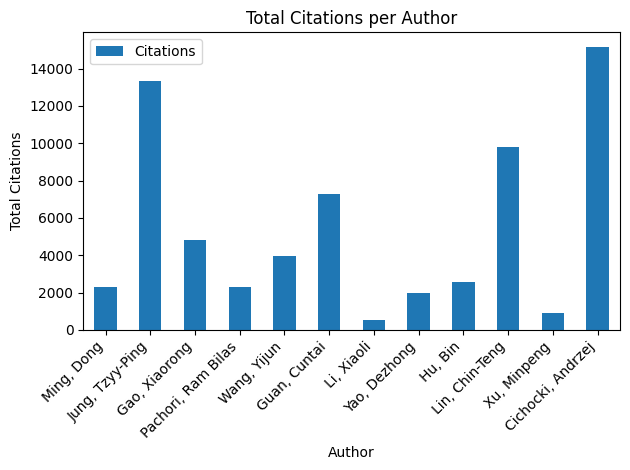

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming your DataFrame is named 'df'

# Check the data types of your columns
print(df.dtypes)

# Identify the columns you want to plot numerically
numeric_columns_to_plot = ['Citations', 'Citations/year_numeric', 'Hirsch h-index'] # Add others as needed

# Try converting these columns to numeric, coercing errors to NaN
for col in numeric_columns_to_plot:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        print(f"Column '{col}' converted to numeric (errors coerced).")
    else:
        print(f"Warning: Column '{col}' not found in DataFrame.")

# Re-check the data types after conversion
print("\nData types after attempted conversion:")
print(df.dtypes)

# Now try plotting again (example for Total Citations)
if 'Author' in df.columns and 'Citations' in df.columns:
    plt.figure(figsize=(10, 6))
    df.plot(x='Author', y='Citations', kind='bar')
    plt.xlabel('Author')
    plt.ylabel('Total Citations')
    plt.title('Total Citations per Author')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Error: 'Author' or 'Citations' column not found in the DataFrame.")

# You can repeat the plotting code for other numeric columns

In [ ]:
import matplotlib.pyplot as plt

if 'Author' in df.columns and 'Citations/year_numeric' in df.columns and 'Hirsch h-index' in df.columns:
    plt.figure(figsize=(10, 6))
    plt.scatter(df['Hirsch h-index'], df['Citations/year_numeric'])
    for i, row in df.iterrows():
        plt.annotate(row['Author'], (row['Hirsch h-index'], row['Citations/year_numeric']), textcoords="offset points", xytext=(5,5), ha='left')
    plt.xlabel('Hirsch h-index')
    plt.ylabel('Citations per Year')
    plt.title('Citations per Year vs. Hirsch h-index')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("Error: Required columns not found in the DataFrame.")

Error: Required columns not found in the DataFrame.
